In [ ]:
!uv pip install transformers accelerate torch sentencepiece huggingface_hub pyyaml --upgrade

Using Python 3.14.6 environment at: c:\Users\user\Downloads\AI-Training\.venv
Resolved 38 packages in 958ms
Checked 38 packages in 12ms


In [12]:
# Task 3: Few-Shot Prompting

import os
import warnings
import logging
import torch

from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Suppress Warnings
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

# Load Environment Variables
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

# Model Name
model_name = "HuggingFaceTB/SmolLM2-360M-Instruct"

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN)

# Load Model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    token=HF_TOKEN,
    torch_dtype=torch.float32
)

# Create Hugging Face Pipeline
chatbot = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer
)

# The 3 Examples
few_shot_examples = """Example 1

Input:
Patient has cough and fever.

Output:
Symptoms:
- Cough
- Fever

Severity:
Moderate

----------------------------------------

Example 2

Input:
Patient complains of headache, nausea, and dizziness.

Output:
Symptoms:
- Headache
- Nausea
- Dizziness

Severity:
Mild

----------------------------------------

Example 3

Input:
Patient has chest pain, shortness of breath, and oxygen level of 88%.

Output:
Symptoms:
- Chest pain
- Shortness of breath

Severity:
Severe

----------------------------------------"""

# System Instructions
system_instructions = "You are MediAssist AI. Convert clinical notes into structured summaries using the exact format provided."

print("\n(Type 'exit' to quit)\n")

# Interactive Chat with User Input
while True:
    # First, wait for you to type your input
    patient_note = input("User Input: ").strip()
    
    if patient_note.lower() == "exit":
        break
        
    messages = [
        {"role": "system", "content": f"{system_instructions}\n\n{few_shot_examples}"},
        {"role": "user", "content": f"Input:\n{patient_note}\n\nOutput:\n"}
    ]

    # Generate Response
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    response = chatbot(
        prompt,
        max_new_tokens=200,
        do_sample=False,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

    answer = response[0]["generated_text"][len(prompt):].strip()

    #THEN print the 3 examples PLUS your input and output all together!
    print(few_shot_examples)
    print(f"\nInput:\n{patient_note}")
    print(f"\nOutput:\n{answer}\n")
    print("----------------------------------------\n")


Loading weights: 100%|██████████| 290/290 [00:18<00:00, 15.52it/s] 



(Type 'exit' to quit)

Example 1

Input:
Patient has cough and fever.

Output:
Symptoms:
- Cough
- Fever

Severity:
Moderate

----------------------------------------

Example 2

Input:
Patient complains of headache, nausea, and dizziness.

Output:
Symptoms:
- Headache
- Nausea
- Dizziness

Severity:
Mild

----------------------------------------

Example 3

Input:
Patient has chest pain, shortness of breath, and oxygen level of 88%.

Output:
Symptoms:
- Chest pain
- Shortness of breath

Severity:
Severe

----------------------------------------

Input:
I have fever , cold , and heache

Output:
Symptoms:
- Fever
- Cold
- Headache

Severity:
Moderate

----------------------------------------

----------------------------------------



KeyboardInterrupt: Interrupted by user

In [ ]:
# The 3 Examples Prompt
few_shot_examples = """Example 1

Input:
Patient has cough and fever.

Output:
Symptoms:
- Cough
- Fever

Severity:
Moderate

----------------------------------------

Example 2

Input:
Patient complains of headache, nausea, and dizziness.

Output:
Symptoms:
- Headache
- Nausea
- Dizziness

Severity:
Mild

----------------------------------------

Example 3

Input:
Patient has chest pain, shortness of breath, and oxygen level of 88%.

Output:
Symptoms:
- Chest pain
- Shortness of breath

Severity:
Severe

----------------------------------------"""

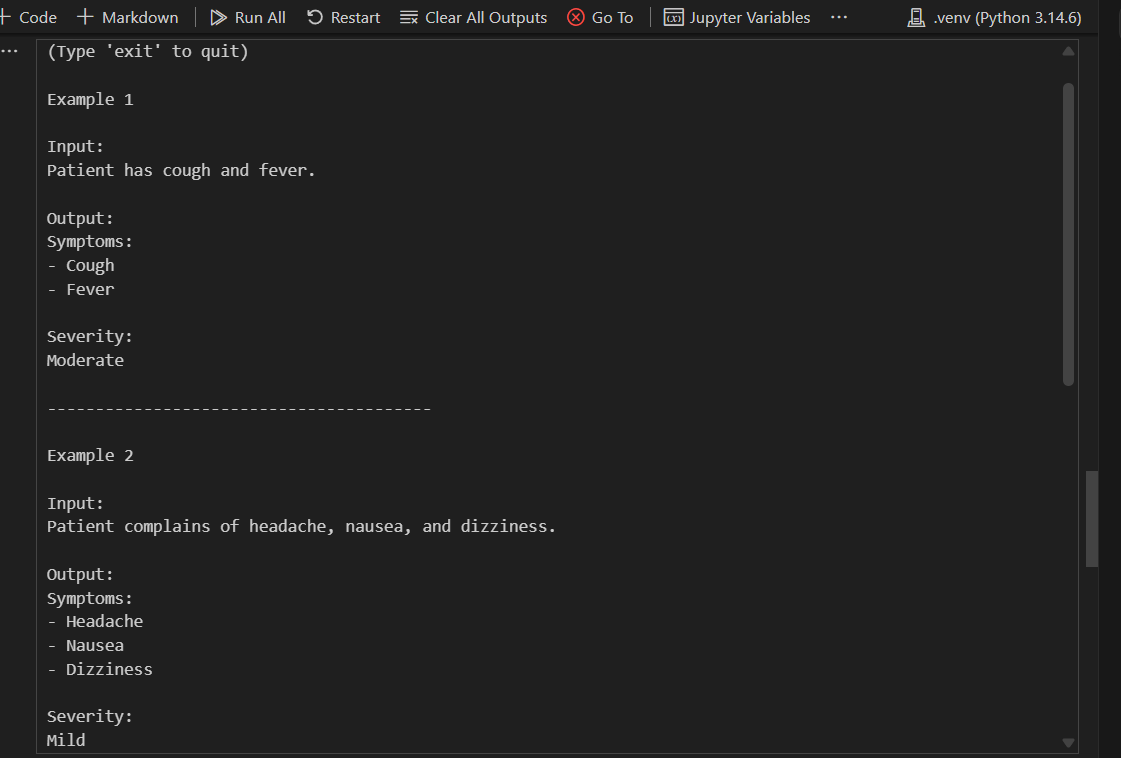 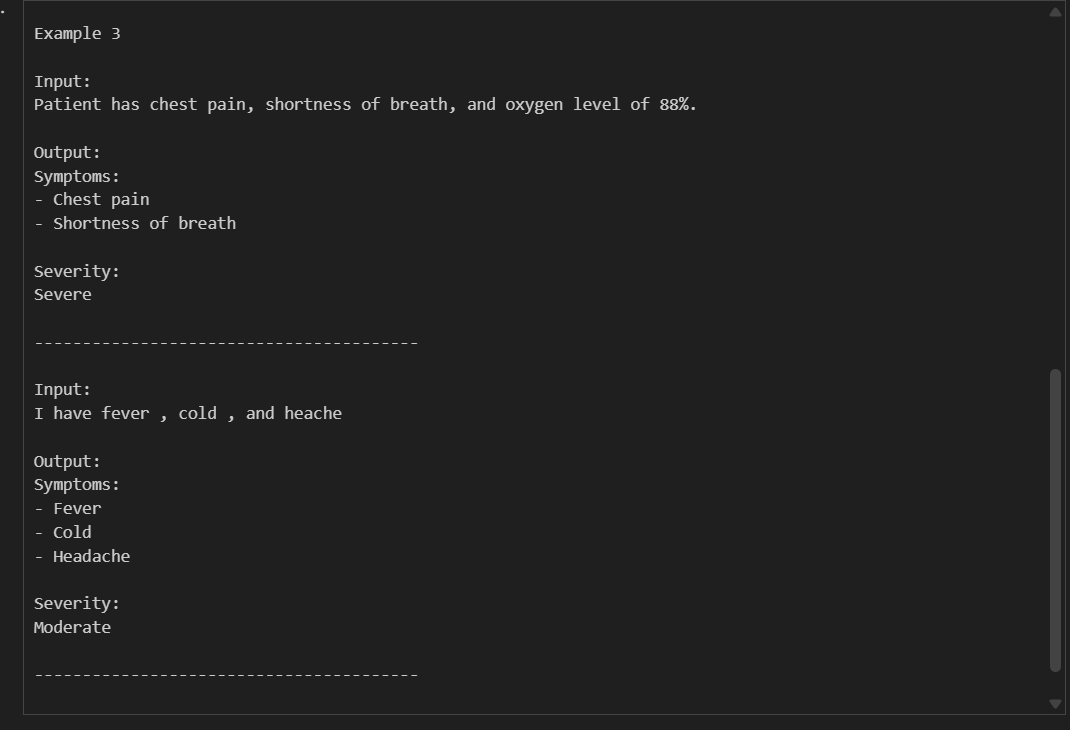

## Short Report

### Prompt Engineering Technique Used
- Used **Chain of Thought Prompting** to encourage step-by-step reasoning.
- Instructed the model to analyze symptoms before providing a recommendation.
- Requested only the **final recommendation** without revealing internal reasoning.
- Structured the output for clarity and consistency.

---

### Challenges Faced
- Designing a prompt that encourages reasoning without exposing the model's internal thought process.
- Preventing the model from making unsupported medical diagnoses.
- Ensuring concise and well-structured responses.

---

### Improvements Made After Prompt Refinement
- Added clear instructions for systematic symptom analysis.
- Included safety constraints to avoid hallucinations and diagnoses.
- Improved response structure using headings and bullet points.
- Ensured the final output contains only the recommendation and disclaimer.